In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import datetime

In [3]:
import yfinance as yf

In [4]:
aapl = yf.Ticker("aapl")

In [5]:
dataset = aapl.history(start = "2015-01-01", end = datetime.datetime.now())

In [6]:
dataset.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00-05:00,24.648436,24.659500,23.754462,24.192598,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,23.962479,24.042140,23.325192,23.511066,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,23.575232,23.772171,23.152585,23.513273,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,23.721276,23.942557,23.610636,23.842981,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,24.170479,24.816618,24.053199,24.759085,237458000,0.0,0.0


In [7]:
tstart = 2019
tend = 2023

In [8]:
feature_columns = ["Open", "Close"]
target_column = ["Close"]

# Inputs
training_features = dataset.loc[
    f"{tstart}":f"{tend}",
    feature_columns
].copy()

test_features = dataset.loc[
    f"{tend + 1}":,
    feature_columns
].copy()

# Output: Close only
training_target = dataset.loc[
    f"{tstart}":f"{tend}",
    target_column
].copy()

test_target = dataset.loc[
    f"{tend + 1}":,
    target_column
].copy()

# Keep these names so your earlier plotting cell still works
train_set = training_features
test_set = test_features

In [9]:
train_set.head()

,Open,Close
Date,,
2019-01-02 00:00:00-05:00,36.750285,37.469204
2019-01-03 00:00:00-05:00,34.161698,33.736992
2019-01-04 00:00:00-05:00,34.292196,35.177200
2019-01-07 00:00:00-05:00,35.281600,35.098904
2019-01-08 00:00:00-05:00,35.485653,35.768002


In [10]:
test_set.head()

,Open,Close
Date,,
2024-01-02 00:00:00-05:00,185.055288,183.562195
2024-01-03 00:00:00-05:00,182.158081,182.187744
2024-01-04 00:00:00-05:00,180.111251,179.873947
2024-01-05 00:00:00-05:00,179.953062,179.152115
2024-01-08 00:00:00-05:00,180.051916,183.483078


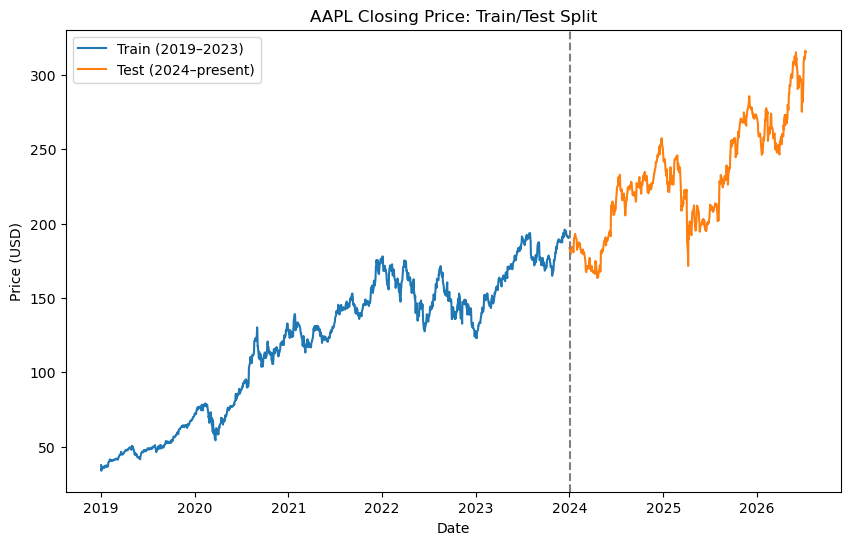

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(train_set.index, train_set['Close'], label='Train (2019–2023)')
plt.plot(test_set.index, test_set['Close'], label='Test (2024–present)')
plt.axvline(x=test_set.index[0], color='gray', linestyle='--')
plt.title('AAPL Closing Price: Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [12]:
def create_dataset(features, targets, lookback):
    X, y = [], []
    
    for i in range(len(features) - lookback):
        feature = features[i:i+lookback]
        target = targets[i+lookback]
        
        X.append(feature)
        y.append(target)
    return (
        torch.tensor(np.array(X), dtype = torch.float32), 
        torch.tensor(np.array(y), dtype = torch.float32)
    )

In [13]:
class AppleModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Test 1: change number of input to 2 to include Open (easier to handle than Volume)
        self.ltsm = nn.LSTM(input_size = 2, hidden_size = 32, num_layers = 1, batch_first =True)
        self.linear = nn.Linear(32, 1)
        
    def forward(self, x):
        x, _ = self.ltsm(x)

        x = x[:, -1, :]
        
        x = self.linear(x)
        return x

In [14]:
from sklearn.preprocessing import MinMaxScaler

# names of groups = training_features, training_target, test_features, test_target

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range= (0,1))

training_features_scaled = feature_scaler.fit_transform(training_features)
training_target_scaled = target_scaler.fit_transform(training_target)

test_features_scaled =  feature_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

In [15]:
# convert everything to float32 to ensure works with pytorch
train_features_array = training_features_scaled.astype("float32")
train_target_array = training_target_scaled.astype("float32")

test_features_array = test_features_scaled.astype("float32")
test_target_array = test_target_scaled.astype("float32")

In [16]:
lookback = 60

X_train, y_train = create_dataset(train_features_array, train_target_array, lookback)

# add historical input context (starts at 2024, however, model does have historical information from before)
test_features_with_context = np.vstack([
    train_features_array[-lookback:],
    test_features_array
])

# align the target value with historical context
test_target_with_context = np.vstack([
    train_target_array[-lookback:],
    test_target_array
])

# generate correct trest window
X_test, y_test = create_dataset(
    test_features_with_context,
    test_target_with_context,
    lookback
)

In [17]:
# Updated Shape for Train & Test
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([1198, 60, 2])
y_train: torch.Size([1198, 1])
X_test: torch.Size([632, 60, 2])
y_test: torch.Size([632, 1])


In [18]:
# training and verifying
torch.manual_seed(2222)

model = AppleModel()
# can input learning rate by putting lr inside the optimizer after parameters. Use Default for now
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle = True, batch_size = 8)

n_epochs = 1000

# separate train and test RMSE
train_rmse_history = []
test_rmse_history = []

# Evaluation epoch addition for graph purposes:
evaluation_epochs = []

for epoch in range(n_epochs):
    model.train()
    
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluation
    if epoch % 10 != 0:
        continue
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train)
        test_pred = model(X_test)

        train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()
        test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()
        
        train_rmse_history.append(train_rmse)
        test_rmse_history.append(test_rmse)
        evaluation_epochs.append(epoch)
        
        print(
        f"Epoch {epoch}: "
        f"train RMSE = {train_rmse:.4f}, "
        f"test RMSE = {test_rmse:.4f}"
        )

Epoch 0: train RMSE = 0.0458, test RMSE = 0.1620
Epoch 10: train RMSE = 0.0221, test RMSE = 0.0571
Epoch 20: train RMSE = 0.0203, test RMSE = 0.0561
Epoch 30: train RMSE = 0.0196, test RMSE = 0.0428
Epoch 40: train RMSE = 0.0171, test RMSE = 0.0398
Epoch 50: train RMSE = 0.0174, test RMSE = 0.0307
Epoch 60: train RMSE = 0.0165, test RMSE = 0.0248
Epoch 70: train RMSE = 0.0153, test RMSE = 0.0317
Epoch 80: train RMSE = 0.0150, test RMSE = 0.0245
Epoch 90: train RMSE = 0.0162, test RMSE = 0.0331
Epoch 100: train RMSE = 0.0148, test RMSE = 0.0268
Epoch 110: train RMSE = 0.0158, test RMSE = 0.0295
Epoch 120: train RMSE = 0.0148, test RMSE = 0.0278
Epoch 130: train RMSE = 0.0148, test RMSE = 0.0297
Epoch 140: train RMSE = 0.0150, test RMSE = 0.0309
Epoch 150: train RMSE = 0.0151, test RMSE = 0.0357
Epoch 160: train RMSE = 0.0167, test RMSE = 0.0371
Epoch 170: train RMSE = 0.0162, test RMSE = 0.0403
Epoch 180: train RMSE = 0.0149, test RMSE = 0.0283
Epoch 190: train RMSE = 0.0147, test RMSE 

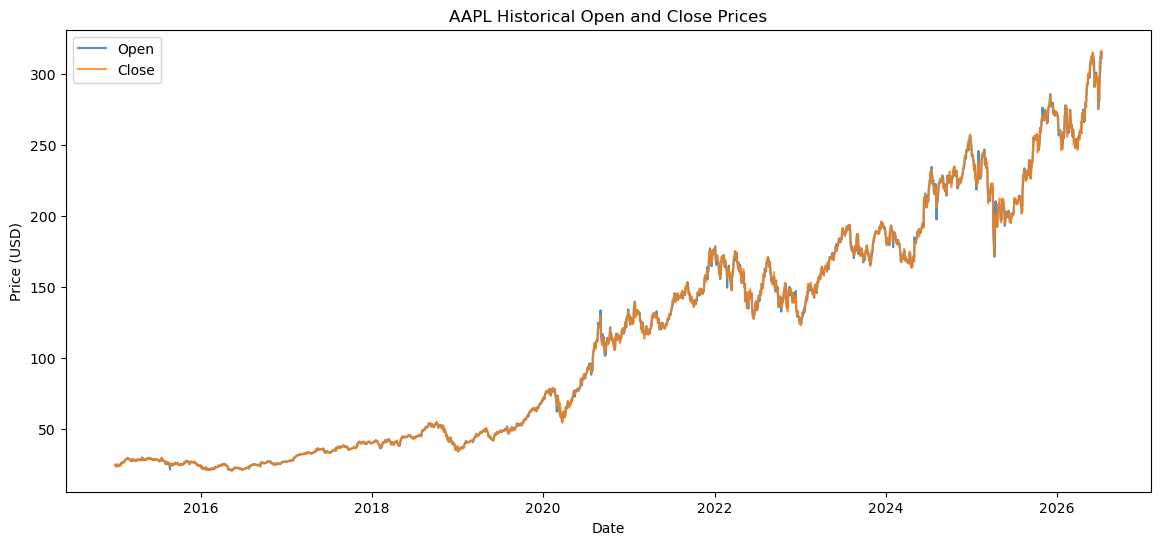

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(dataset.index, dataset["Open"], label="Open", alpha=0.8)
plt.plot(dataset.index, dataset["Close"], label="Close", alpha=0.8)

plt.title("AAPL Historical Open and Close Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

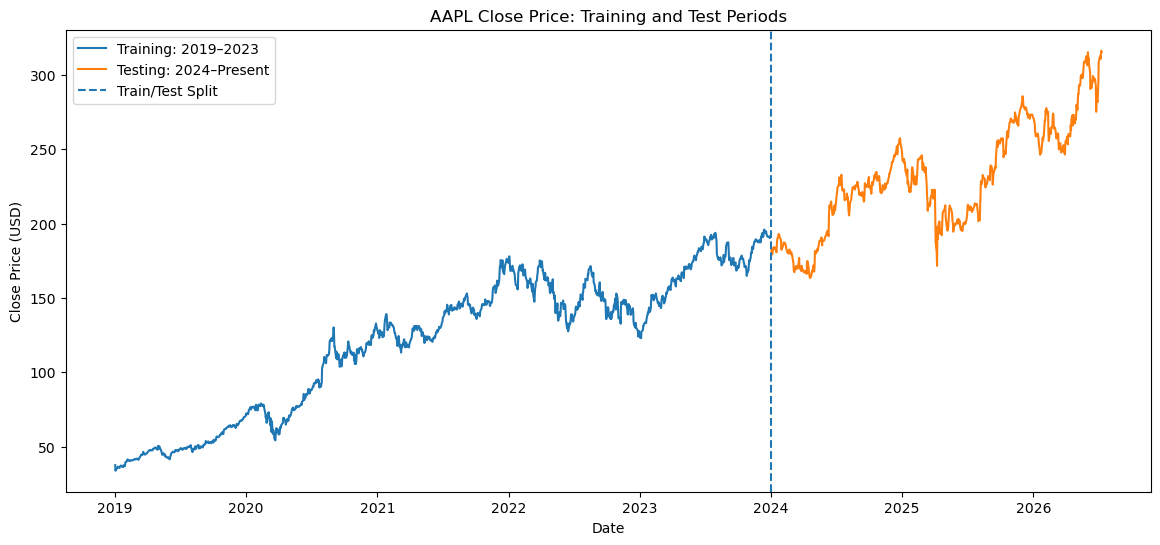

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    training_target.index,
    training_target["Close"],
    label="Training: 2019–2023"
)

plt.plot(
    test_target.index,
    test_target["Close"],
    label="Testing: 2024–Present"
)

plt.axvline(
    test_target.index[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("AAPL Close Price: Training and Test Periods")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.show()

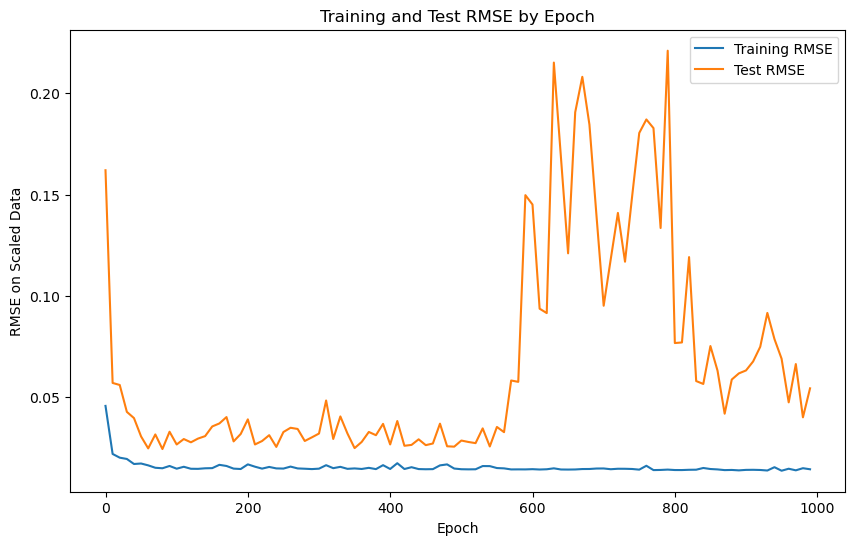

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    evaluation_epochs,
    train_rmse_history,
    label="Training RMSE"
)

plt.plot(
    evaluation_epochs,
    test_rmse_history,
    label="Test RMSE"
)

plt.title("Training and Test RMSE by Epoch")
plt.xlabel("Epoch")
plt.ylabel("RMSE on Scaled Data")
plt.legend()
plt.show()

In [22]:
model.eval()

with torch.no_grad():
    test_predictions_scaled = model(X_test).numpy()

test_predictions = target_scaler.inverse_transform(
    test_predictions_scaled
).flatten()

actual_test_prices = target_scaler.inverse_transform(
    y_test.numpy()
).flatten()

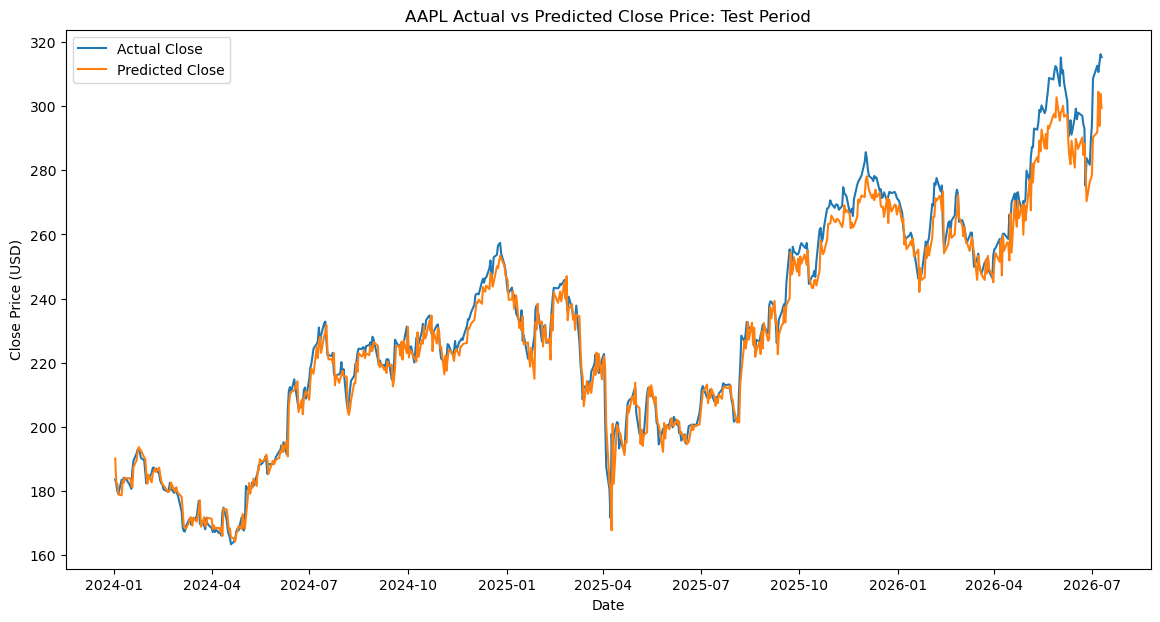

In [23]:
plt.figure(figsize=(14, 7))

plt.plot(
    test_target.index,
    actual_test_prices,
    label="Actual Close"
)

plt.plot(
    test_target.index,
    test_predictions,
    label="Predicted Close"
)

plt.title("AAPL Actual vs Predicted Close Price: Test Period")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.show()